In [1]:
!pip install spectral tqdm scikit-learn

from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 5.9 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
import os
import numpy as np
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import scipy.io as sio
import spectral

from scipy.io import loadmat
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix
from tensorflow.keras.layers import (
    Input,
    Conv3D,
    Conv2D,
    Dense,
    Dropout,
    Reshape,
    Permute,
    Add,
    Multiply,
    Activation,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Concatenate,
    Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint


In [3]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [4]:
def loadData(name):

    data_path = '/content/drive/MyDrive/datasets'

    if name == 'Tangdaowan':
        data = loadmat(os.path.join(data_path, 'QUH-Tangdaowan.mat'))['Tangdaowan']
        labels = loadmat(os.path.join(data_path, 'QUH-Tangdaowan_GT.mat'))['TangdaowanGT']
        class_name = [
            "Rubber track","Flaggingv","Sandy","Asphalt","Boardwalk",
            "Rocky shallows","Grassland","Bulrush","Gravel road",
            "Ligustrum vicaryi","Coniferous pine","Spiraea","Bare soil",
            "Buxus sinica","Photinia serrulata","Populus",
            "Ulmus pumila L","Seawater"
        ]

    elif name == 'Qingyun':
        data = loadmat(os.path.join(data_path, 'QUH-Qingyun.mat'))['Chengqu']
        labels = loadmat(os.path.join(data_path, 'QUH-Qingyun_GT.mat'))['ChengquGT']
        class_name = [
            "Trees","Concrete building","Car",
            "Ironhide building","Plastic playground","Asphalt road"
        ]

    elif name == 'Pingan':
        data = loadmat(os.path.join(data_path, 'QUH-Pingan.mat'))['Haigang']
        labels = loadmat(os.path.join(data_path, 'QUH-Pingan_GT.mat'))['HaigangGT']
        class_name = [
            "Ship","Seawater","Trees","Concrete structure building",
            "Floating pier","Asphalt road","Brick houses",
            "Steel houses","Wharf construction land","Car","Road"
        ]

    return data, labels, class_name


# ===========================
# PCA
# ===========================

def applyPCA(X, numComponents=15, normalization=True):

    newX = np.reshape(X, (-1, X.shape[2]))

    if numComponents != 0:
        pca = PCA(n_components=numComponents)
        newX = pca.fit_transform(newX)

    if normalization:
        newX = minmax_scale(newX, axis=1)

    newX = np.reshape(newX, (X.shape[0], X.shape[1], -1))

    return newX


def get_img_indexes(class_map, removeZeroindexes=True):

    if removeZeroindexes:
        indices = np.argwhere(class_map != 0)
    else:
        indices = np.argwhere(class_map != None)

    labels = class_map[indices[:, 0], indices[:, 1]]
    indices = [tuple(idx) for idx in indices]

    return indices, np.array(labels.tolist()) - 1


def createImageCubes(X, indices, windowSize):

    margin = windowSize // 2
    N, M, P = X.shape

    X_padded = np.zeros((N + 2 * margin, M + 2 * margin, P))
    X_padded[margin:N + margin, margin:M + margin, :] = X

    patches = []

    for idx in indices:
        i, j = idx
        i += margin
        j += margin

        patch = X_padded[i - margin:i + margin + 1,
                         j - margin:j + margin + 1, :]

        patches.append(patch)

    return np.array(patches)


# ===========================
# TRAIN TEST SPLIT
# ===========================

def splitTrainTestSet(X, y, testRatio):
    return train_test_split(
        X,
        y,
        test_size=testRatio,
        stratify=y,
        random_state=42   # FIXED SEED
    )


def predict_by_batching(model, input_tensor_idx, batch_size, X, windowSize):

    num_samples = len(input_tensor_idx)
    predictions = []

    for i in tqdm(range(0, num_samples, batch_size), desc="Predicting"):
        batch = createImageCubes(
            X, input_tensor_idx[i:i + batch_size], windowSize
        )

        batch = np.expand_dims(batch, axis=-1)
        batch_predictions = model.predict(batch, verbose=0)
        predictions.append(batch_predictions)

    return np.concatenate(predictions, axis=0)


# ===========================
# CLASS MAP GENERATION
# ===========================

def get_class_map(model, X, label, window_size):

    indexes, labels = get_img_indexes(label, removeZeroindexes=False)

    y_pred = predict_by_batching(model, indexes, 10000, X, window_size)
    y_pred = np.argmax(y_pred, axis=1).astype(np.uint8)

    return np.reshape(y_pred, label.shape) + 1


def img_display(data=None, rgb_band=None, classes=None,
                title=None, figsize=(7,7), palette=spectral.spy_colors):

    if data is not None:
        im_rgb = data[:, :, rgb_band]
        im_rgb = im_rgb / np.max(im_rgb) * 255
        im_rgb = np.asarray(im_rgb, np.uint8)

        plt.figure(figsize=figsize)
        plt.imshow(im_rgb)
        plt.title(title)
        plt.axis('off')

    elif classes is not None:
        rgb_class = np.zeros((classes.shape[0], classes.shape[1], 3))

        for i in np.unique(classes):
            rgb_class[classes == i] = palette[i]

        rgb_class = np.asarray(rgb_class, np.uint8)

        plt.figure(figsize=figsize)
        plt.imshow(rgb_class)
        plt.title(title)
        plt.axis('off')


In [5]:
DATASET = 'Tangdaowan'

data, gt, class_name = loadData(DATASET)

print("Original shape:", data.shape)
print("GT shape:", gt.shape)
print("Number of classes:", len(class_name))


Original shape: (1740, 860, 176)
GT shape: (1740, 860)
Number of classes: 18


In [6]:
data = applyPCA(data, numComponents=15, normalization=True)
data = data.astype(np.float32)

print("After PCA shape:", data.shape)


After PCA shape: (1740, 860, 15)


In [7]:
indexes, labels = get_img_indexes(gt, removeZeroindexes=True)

X_train_idx, X_test_idx, y_train, y_test = splitTrainTestSet(
    indexes, labels, testRatio=0.95)

X_train_idx, X_val_idx, y_train, y_val = splitTrainTestSet(
    X_train_idx, y_train, testRatio=0.30
)

print("Train samples:", len(y_train))
print("Val samples:", len(y_val))
print("Test samples:", len(y_test))


Train samples: 19507
Val samples: 8361
Test samples: 529498


In [8]:
window_size = 9

X_train = createImageCubes(data, X_train_idx, window_size)
X_val   = createImageCubes(data, X_val_idx, window_size)

print("Patch shape:", X_train.shape)


Patch shape: (19507, 9, 9, 15)


In [9]:
X_train = np.expand_dims(X_train, axis=-1)
X_val   = np.expand_dims(X_val, axis=-1)

print("New shape:", X_train.shape)


New shape: (19507, 9, 9, 15, 1)


In [10]:
import tensorflow as tf

y_train = tf.keras.utils.to_categorical(y_train)
y_val   = tf.keras.utils.to_categorical(y_val)


In [11]:
def spectral_mixer_block(x, hidden_dim, num_blocks=4):

    H, W, C, D = x.shape[1:]

    x = Permute((1, 2, 4, 3))(x)
    x = Reshape((H*W, D, C))(x)

    for _ in range(num_blocks):
        x1 = Dense(hidden_dim)(x)
        x1 = Dense(C)(x1)
        x = Add()([x, x1])

    return Reshape((H, W, C, D))(x)


In [12]:
def spatial_mixer_block(x, hidden_dim, num_blocks=4):

    H, W, C, D = x.shape[1:]

    x = Permute((3, 4, 1, 2))(x)
    x = Reshape((C, D, H*W))(x)

    for _ in range(num_blocks):
        x1 = Dense(hidden_dim)(x)
        x1 = Dense(H*W)(x1)
        x = Add()([x, x1])

    x = Permute((3, 1, 2))(x)
    return Reshape((H, W, C, D))(x)


In [ ]:
# def dw_attention_block(x):

#     # Get static shape (allowed)
#     H, W, C, F = x.shape[1], x.shape[2], x.shape[3], x.shape[4]

#     # Reshape using Keras layer (NOT tf.reshape)
#     x_2D = Reshape((H, W, C * F))(x)

#     x_dw = DepthwiseConv2D(kernel_size=3, padding='same')(x_2D)
#     x_dw = Activation('sigmoid')(x_dw)

#     return Multiply()([x_2D, x_dw])



In [13]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, Dense, Multiply

def se_block(x, reduction=4):

    channels = x.shape[-1]

    se = GlobalAveragePooling2D()(x)
    se = Reshape((1,1,channels))(se)

    se = Dense(channels // reduction, activation='gelu')(se)
    se = Dense(channels, activation='sigmoid')(se)

    return Multiply()([x, se])

In [14]:
def SS_MixNet(img_list, mixer_dim=256, num_classes=len(class_name)):

    input_shape = img_list.shape[1:]
    inp = Input(shape=input_shape)

    # =================================================
    # 3D Convolution Backbone (Stronger Feature Extraction)
    # =================================================
    x = Conv3D(32, (3,3,3), padding='same', activation='gelu')(inp)
    x = Conv3D(64, (3,3,3), padding='same', activation='gelu')(x)

    # =================================================
    # Spectral & Spatial Mixers
    # =================================================
    x_spe = spectral_mixer_block(x, mixer_dim)
    x_spa = spatial_mixer_block(x, mixer_dim)

    # =================================================
    # Fusion (5D Tensor)
    # =================================================
    x = Concatenate(axis=4)([x_spe, x_spa])

    # =================================================
    # Convert 5D → 4D (B, H, W, C*F)
    # =================================================
    H = x.shape[1]
    W = x.shape[2]
    C = x.shape[3]
    F = x.shape[4]
    x = Reshape((H, W, C * F))(x)

    # =================================================
    # Channel Attention (SE Block)
    # =================================================
    x = se_block(x)

    # =================================================
    # Residual Boost Layer (Improved)
    # =================================================
    res = Conv2D(x.shape[-1], 1, padding='same', activation='gelu')(x)
    x = Add()([x, res])

    # =================================================
    # Classification Head
    # =================================================
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    # IMPORTANT: float32 for stability
    out = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )

    return model

In [15]:
model = SS_MixNet(X_train, mixer_dim=256)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9, 9, 15,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 9, 9, 15,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 9, 9, 15,  │     55,360 │ conv3d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 15, 64, 9, │          0 │ conv3d_1[0][0]    │
│                     │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 9, 9, 64,  │          0 │ conv3d_1[0][0]    │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 15, 64,    │          0 │ permute_1[0][0]   │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 81, 64,    │          0 │ permute[0][0]     │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 15, 64,    │     20,992 │ reshape_2[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 81, 64,    │      4,096 │ reshape[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 15, 64,    │     20,817 │ dense_8[0][0]     │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 81, 64,    │      3,855 │ dense[0][0]       │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 15, 64,    │          0 │ reshape_2[0][0],  │
│                     │ 81)               │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 81, 64,    │          0 │ reshape[0][0],    │
│                     │ 15)               │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 15, 64,    │     20,992 │ add_4[0][0]       │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 81, 64,    │      4,096 │ add[0][0]         │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 15, 64,    │     20,817 │ dense_10[0][0]    │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 81, 64,    │      3,855 │ dense_2[0][0]   

 Total params: 5,823,794 (22.22 MB)

 Trainable params: 5,823,794 (22.22 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f"{DATASET}_SS_MixNet.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=8,
    min_lr=5e-5
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=12,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=256,   # T4 optimized
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, lr_callback, early_stop]
)

Epoch 1/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.4254 - loss: 2.0282
Epoch 1: val_accuracy improved from None to 0.76809, saving model to Tangdaowan_SS_MixNet.keras

Epoch 1: finished saving model to Tangdaowan_SS_MixNet.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 597ms/step - accuracy: 0.5774 - loss: 1.5516 - val_accuracy: 0.7681 - val_loss: 0.9454 - learning_rate: 3.0000e-04
Epoch 2/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8047 - loss: 0.8715
Epoch 2: val_accuracy improved from 0.76809 to 0.88123, saving model to Tangdaowan_SS_MixNet.keras

Epoch 2: finished saving model to Tangdaowan_SS_MixNet.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 23s 294ms/step - accuracy: 0.8252 - loss: 0.8116 - val_accuracy: 0.8812 - val_loss: 0.6859 - learning_rate: 3.0000e-04
Epoch 3/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.8748 - loss: 0.6783
Epoch 3: val_accuracy improved from 0.88123 to 0.91484, saving model to Tangdaowan_SS_MixNet.keras

Epoch 3: finished saving model 

In [17]:
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved.")


Training history saved.


In [18]:
from google.colab import files

files.download("training_history.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import numpy as np

np.save("training_history.npy", history.history)

print("Training history saved as training_history.npy")


Training history saved as training_history.npy


In [38]:
from google.colab import files
files.download("training_history.npy")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import seaborn as sns


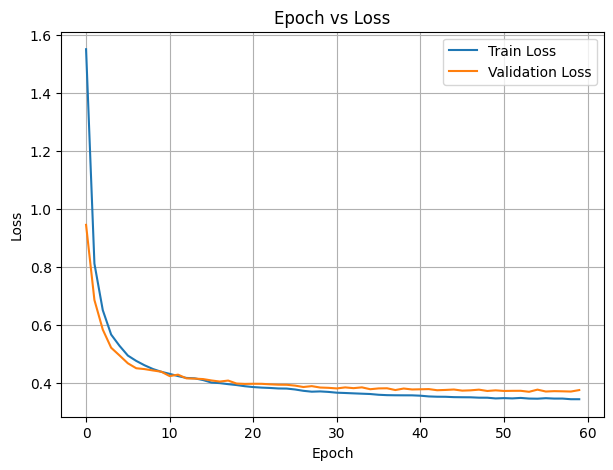

In [20]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


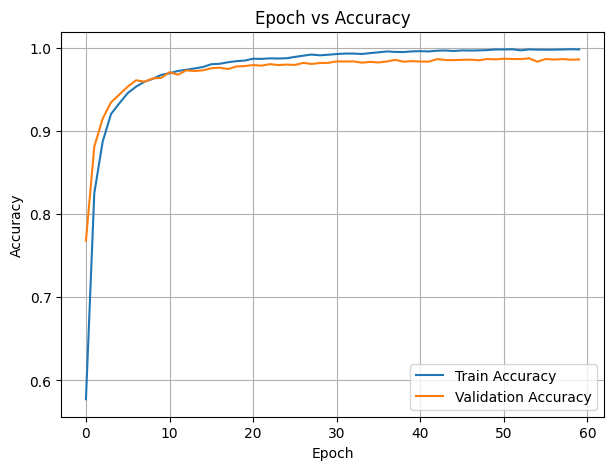

In [21]:
plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Epoch vs Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


Predicting: 100%|██████████| 265/265 [05:17<00:00,  1.20s/it]


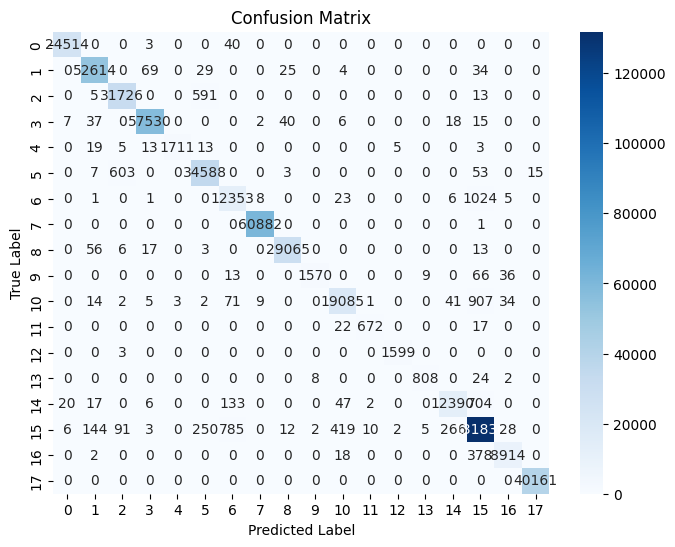

Evaluation Results
Overall Accuracy (OA): 98.59%
Average Accuracy (AA): 97.15%
Kappa Coefficient: 98.39


In [24]:
Y_pred_test = predict_by_batching(
    model,
    input_tensor_idx=X_test_idx,
    batch_size=2000,   # T4 can handle larger batches for inference
    X=data,
    windowSize=window_size
)

y_pred_test = np.argmax(Y_pred_test, axis=1)

# ==============================
# Metrics
# ==============================

oa = accuracy_score(y_test, y_pred_test)
kappa = cohen_kappa_score(y_test, y_pred_test)

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()


# Safe class accuracy calculation
class_acc = np.zeros(cm.shape[0])
for i in range(cm.shape[0]):
    if cm.sum(axis=1)[i] != 0:
        class_acc[i] = cm[i, i] / cm.sum(axis=1)[i]

aa = np.mean(class_acc)

# ==============================
# Print Results
# ==============================

print("="*60)
print("Evaluation Results")
print("="*60)
print(f"Overall Accuracy (OA): {oa*100:.2f}%")
print(f"Average Accuracy (AA): {aa*100:.2f}%")
print(f"Kappa Coefficient: {kappa*100:.2f}")
print("="*60)

In [34]:
import json

test_metrics = {
    "Overall Accuracy (OA)": float(oa),
    "Average Accuracy (AA)": float(aa),
    "Kappa Score": float(kappa)
}

with open("test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Test metrics saved.")


Test metrics saved.


In [35]:
from google.colab import files

files.download("test_metrics.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import pandas as pd

cm_df = pd.DataFrame(cm, index=class_name, columns=class_name)

cm_df.to_csv("confusion_matrix_test.csv")

print("Confusion matrix saved.")


Confusion matrix saved.


In [33]:
from google.colab import files

files.download("confusion_matrix_test.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from sklearn.metrics import classification_report

In [26]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=class_name,
        digits=4
    )
)



Classification Report:

                    precision    recall  f1-score   support

      Rubber track     0.9987    0.9982    0.9985     24557
         Flaggingv     0.9943    0.9969    0.9956     52775
             Sandy     0.9781    0.9812    0.9796     32335
           Asphalt     0.9980    0.9978    0.9979     57655
         Boardwalk     0.9982    0.9672    0.9825      1769
    Rocky shallows     0.9750    0.9807    0.9778     35269
         Grassland     0.9222    0.9204    0.9213     13421
           Bulrush     0.9997    1.0000    0.9998     60883
       Gravel road     0.9973    0.9967    0.9970     29160
 Ligustrum vicaryi     0.9937    0.9268    0.9591      1694
   Coniferous pine     0.9725    0.9460    0.9591     20174
           Spiraea     0.9810    0.9451    0.9628       711
         Bare soil     0.9956    0.9981    0.9969      1602
      Buxus sinica     0.9830    0.9596    0.9712       842
Photinia serrulata     0.9740    0.9303    0.9516     13319
           Pop

In [28]:
import pandas as pd

report = classification_report(
    y_test,
    y_pred_test,
    target_names=class_name,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report.to_csv("classification_report.csv")

pd.DataFrame(cm).to_csv("confusion_matrix.csv")

print("Results saved.")


Results saved.


In [29]:
import pandas as pd

report_df = pd.DataFrame(report).transpose()

report_df.to_csv("classification_report.csv")

print("Classification report saved.")


Classification report saved.


In [30]:
from google.colab import files

files.download("classification_report.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import pandas as pd
import numpy as np

# -----------------------------
# Compute per-class accuracy
# -----------------------------
class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

rows = []

for i in range(len(class_name)):

    train_count = (y_train.argmax(axis=1) == i).sum()
    val_count   = (y_val.argmax(axis=1) == i).sum()
    test_count  = (y_test == i).sum()
    total_count = (gt == (i+1)).sum()

    rows.append([
        class_name[i],
        train_count,
        val_count,
        test_count,
        total_count,
        round(class_accuracy[i], 2)
    ])

# -----------------------------
# Create DataFrame
# -----------------------------
df = pd.DataFrame(
    rows,
    columns=[
        "Class",
        "Train",
        "Val",
        "Test",
        "Total",
        "SS-MixNet (%)"
    ]
)

# -----------------------------
# Summary Metrics
# -----------------------------
summary_rows = pd.DataFrame([
    ["OA (%)", "", "", "", "", round(oa * 100, 2)],
    ["AA (%)", "", "", "", "", round(aa * 100, 2)],
    ["Kappa (×100)", "", "", "", "", round(kappa * 100, 2)]
], columns=df.columns)

df_final = pd.concat([df, summary_rows], ignore_index=True)

# -----------------------------
# Pretty Print Table
# -----------------------------
print("\n")
print("=" * 90)
print(f"{'Classification Performance of SS-MixNet on ' + DATASET:^90}")
print("=" * 90)

print(f"{'Class':<25}{'Train':>8}{'Val':>8}{'Test':>10}{'Total':>10}{'Accuracy (%)':>15}")
print("-" * 90)

for i in range(len(class_name)):
    print(f"{df.iloc[i,0]:<25}"
          f"{df.iloc[i,1]:>8}"
          f"{df.iloc[i,2]:>8}"
          f"{df.iloc[i,3]:>10}"
          f"{df.iloc[i,4]:>10}"
          f"{df.iloc[i,5]:>15}")

print("-" * 90)

print(f"{'Overall Accuracy (OA)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(oa*100,2):>15}")
print(f"{'Average Accuracy (AA)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(aa*100,2):>15}")
print(f"{'Kappa (×100)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(kappa*100,2):>15}")

print("=" * 90)




                  Classification Performance of SS-MixNet on Tangdaowan                   
Class                       Train     Val      Test     Total   Accuracy (%)
------------------------------------------------------------------------------------------
Rubber track                  904     388     24557     25849          99.82
Flaggingv                    1945     833     52775     55553          99.69
Sandy                        1191     511     32335     34037          98.12
Asphalt                      2124     911     57655     60690          99.78
Boardwalk                      65      28      1769      1862          96.72
Rocky shallows               1299     557     35269     37125          98.07
Grassland                     494     212     13421     14127          92.04
Bulrush                      2243     961     60883     64087          100.0
Gravel road                  1075     460     29160     30695          99.67
Ligustrum vicaryi              62      27     

Predicting: 100%|██████████| 150/150 [12:38<00:00,  5.05s/it]


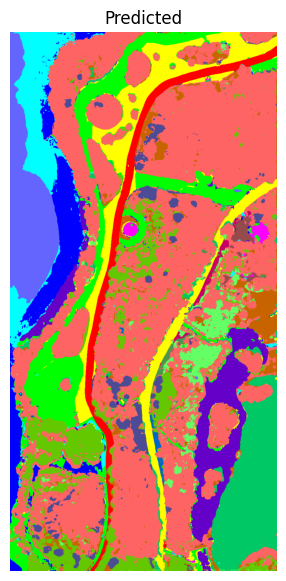

In [36]:
model.load_weights(f"{DATASET}_SS_MixNet.keras")


Predicted_Class_Map = get_class_map(model, data, gt, window_size)

img_display(classes=Predicted_Class_Map, title='Predicted')


In [39]:
model.save("SS_MixNet_Updated_new_SE.keras")

In [40]:
from google.colab import files
files.download("SS_MixNet_Updated_new_SE.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
import numpy as np

np.save("X_test_idx_SE.npy", X_test_idx)
np.save("y_test_SE.npy", y_test)

files.download("X_test_idx_SE.npy")
files.download("y_test_SE.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
model.save_weights("SS_MixNet_Updated_new_SE.weights.h5")
files.download("SS_MixNet_Updated_new_SE.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>